# BMA MCMC
- After having implemented the MCMC, I feel the model selection is still a point of unresolved uncertainty.
- Examining the NLLs, the models have can have similar NLL values but we choose just one model.
- Rather than using a full RJMCMC, we can approximate the model selection by MCMC sampling the top few models and then creating a multi-model sample-set by proportionally sampling from the model samples according to their likelihood.
- We can use softmax to assign the probabilities.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import emcee

from scipy.optimize import minimize
from scipy.special import softmax

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def lnPost(log_params, gp, k, y, initial_guesses, bounds, prior_std=3):
    if np.any(log_params < bounds[:, 0]) or np.any(log_params > bounds[:, 1]):
        return -np.inf
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    ll = gp.log_likelihood(y)
    if not np.isfinite(ll):
        return -np.inf
    return ll - 0.5 * np.sum(((np.exp(log_params) - np.exp(initial_guesses)) / prior_std) ** 2)

from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_all_samplers(combo_samplers, prior_combos, discard=1000):
    n_combos = len(combo_samplers)

    combo_param_names = {}
    for combo_name in combo_samplers:
        cycle_keys = prior_combos[combo_name]['cycle_keys']
        combo_param_names[combo_name] = (
            [f'σ_{ck}' for ck in cycle_keys] +
            [f'ρ_{ck}'  for ck in cycle_keys] +
            [f'Q_{ck}'  for ck in cycle_keys]
        )

    max_params = max(len(v) for v in combo_param_names.values())

    fig, axes = plt.subplots(
        max_params, n_combos,
        figsize=(5 * n_combos, 2.5 * max_params),
        squeeze=False
    )

    for col, (combo_name, sampler) in enumerate(combo_samplers.items()):
        samples = sampler.get_chain(discard=discard)  # (n_steps, n_walkers, n_params)
        param_names = combo_param_names[combo_name]
        n_params = len(param_names)

        axes[0, col].set_title(combo_name, fontsize=12, fontweight='bold')

        for row in range(max_params):
            ax = axes[row, col]
            if row < n_params:
                param_samples = np.exp(samples[:, :, row])
                ax.plot(param_samples, color='steelblue', alpha=0.3, lw=0.5)
                ax.set_ylabel(param_names[row], fontsize=9)
                if row == n_params - 1:
                    ax.set_xlabel('Step', fontsize=9)

                divider = make_axes_locatable(ax)
                ax_hist = divider.append_axes('right', size='25%', pad=0.05)
                ax_hist.hist(param_samples.flatten(), bins=50,
                            orientation='horizontal', color='steelblue',
                            alpha=0.6, density=True)
                ax_hist.set_ylim(ax.get_ylim())
                ax_hist.yaxis.set_visible(False)
                ax_hist.xaxis.set_visible(False)
                for spine in ax_hist.spines.values():
                    spine.set_visible(False)
            else:
                ax.set_visible(False)

    fig.suptitle('MCMC Traces — All Samplers', fontsize=14)
    fig.tight_layout()
    plt.show()


In [3]:
datapath = r"../../Data/benchmark/HD201091_Mt_wilson_data.txt"

direct_bound_tol = 0.1
sm2016_bound_tol = 0.2
mean_bound_tol = 1

add_prefix = False
relative = True
train_split = 0.8
valid_split = 0.19

star_type = "G"
star_name = "HD201091"

error_percent = 2.5
sigma_upper_mult = 5.0
q_bounds_in = [5, 100]

verbose = True
plot = True
loop_verbose = True
loop_plot = False
loop_savefigs = False
results_verbose = True
results_plot = True
ax = None
result_plot_cadence = 50
result_plot_extra = 1000

require_mid = True

n_walkers = 32

SEED = 1701

In [4]:
def train_gpr(
        datapath, 
        direct_bound_tol = 0.1, sm2016_bound_tol = 0.2, 
        mean_bound_tol = 1, # in std
        add_prefix: bool = False, # whether or not to add the 240000 to the JD
        train_split: float = 0.8, valid_split: float = 0.19,
        star_type: str = None, star_name: str = None,
        error_percent: float = 2.5, # the percentage error of the input
        sigma_upper_mult: float = 5.0, q_bounds_in = [5, 100],
        relative: bool = True, # Plot data with relative dates
        verbose = True, plot = True, # general outputs
        loop_verbose: bool = False, loop_plot: bool = False, loop_savefigs: bool = True, # output within the loop
        results_verbose: bool = True, results_plot: bool = True, ax = None, # output the results
        bma_verbose: bool = True, sampler_plot: bool = True, bma_plot: bool = True, # output the BMA results
        result_plot_cadence = 50, # Plot every x days
        result_plot_extra = 1000, # Plot for 100 days extra after end of validation set
        require_mid: bool = True, # discard kernel combos with no mid-range term (prevents underfitting with sparse data)
        total_sample_count: int = 10000, plot_every = 200, # Choose how many to sample total
        n_walkers: int = 32,
        SEED = 1701
    ):

        # Read the data into a "raw" df
        raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

        # Prep the df adds the column names etc
        data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

        # Split the data
        dirty_train_df, dirty_valid_df, test_df = split_df(data_df,
                                                        train_split=train_split, valid_split=valid_split)

        # Clean the dataset for outliers
        train_df, valid_df, _ = clean_df(dirty_train_df, dirty_valid_df, tol=4,
                                verbose=verbose, plot=plot)

        # Classify signal data and get priors
        classified_signal_data = find_classify_signals(dirty_train_df,
                                                plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                                plot_genpriors=plot, verbose_genpriors=verbose)

        rho_priors, rho_prior_bounds, rho_sources = get_priors(classified_signal_data,
                                                                        star_type=star_type,
                                                                        direct_bound_tol = direct_bound_tol, 
                                                                        sm2016_bound_tol = sm2016_bound_tol, 
                                                                        mean_bound_tol = mean_bound_tol,
                                                                        verbose=verbose)

        #-----Do the model training and comparison---------
        train_yerr = train_df['sind'] * error_percent / 100

        train_mean = train_df['sind'].mean()
        train_std  = train_df['sind'].std()

        # Define the prior combos to try (k, [[q_priors], [rho_priors]])
        prior_combos = {
                "1s":    {'k': 1, 'q_priors': None,          'cycle_keys': ['short']},
                "1m":    {'k': 1, 'q_priors': None,          'cycle_keys': ['mid']},
                "1l":    {'k': 1, 'q_priors': None,          'cycle_keys': ['long']},

                "2sm":   {'k': 2, 'q_priors': None,          'cycle_keys': ['short', 'mid']},
                "2ml":   {'k': 2, 'q_priors': None,          'cycle_keys': ['mid',   'long']},
                "2sl":   {'k': 2, 'q_priors': None,          'cycle_keys': ['short', 'long']},

                "3sml":  {'k': 3, 'q_priors': None,          'cycle_keys': ['short', 'mid', 'long']},

                "const": {'k': 1, 'q_priors': "overdamped",  'cycle_keys': ['mid']},
        }

        if require_mid:
                prior_combos = {key: val for key, val in prior_combos.items() if 'mid' in val['cycle_keys']}

        #-----Set up the loop----------
        # We wish to store the NLPD, gp, params, inital_guess, and bounds for all combos 
        combo_results = {} # Dict key = combo name

        #----Run the loop----------
        for combo_name, combo_info in prior_combos.items():

                k = combo_info['k']
                q_prior_type = combo_info['q_priors']
                cycle_keys = combo_info['cycle_keys']

                np.random.seed(SEED)

                # Set up q priors
                if q_prior_type == 'overdamped':
                        q_0s     = [np.random.uniform(0, 0.5) for _ in range(k)]
                else:
                        q_0s     = [np.random.uniform(0.5, 1) for _ in range(k)]

                # Set up remaining priors
                sigma_0s = [train_std / k for _ in range(k)]
                rho_0s = [rho_priors[cycle_key] for cycle_key in cycle_keys]

                # Form initial guess
                initial_guess = np.concatenate([
                        np.log(sigma_0s),
                        np.log(rho_0s),
                        np.log(q_0s)
                ])

                # Set up optimisation bounds
                if q_prior_type == 'overdamped':
                        q_bounds     = [(-np.inf, np.log(0.5)) for _ in range(k)]
                else:
                        q_bounds     = [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]

                sigma_upper  = train_std * sigma_upper_mult
                sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
                rho_bounds   = np.log([rho_prior_bounds[cycle_key] for cycle_key in cycle_keys])

                bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

                # Create the initial kernel for this iteration
                kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
                for k_idx in range(1, k):
                        kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

                # Define and compute the GP
                gp = celerite2.GaussianProcess(kernel, mean=train_mean)
                gp.compute(train_df['day'], yerr=train_yerr)

                # Train the GP
                gp_results = minimize(
                        NLL, initial_guess,
                        args=(gp, k, train_df['sind'].to_numpy()),
                        method='L-BFGS-B',
                        bounds=bounds
                        )

                gp   = set_params(gp_results.x, k, gp)
                gp.recompute()
                best_params = np.exp(gp_results.x)

                # Predict on validation set
                mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
                std = np.sqrt(cov)

                # Model comparison via NLPD
                y_valid    = valid_df['sind'].to_numpy()
                valid_yerr = valid_df['sind'] * error_percent / 100
                total_var  = cov + valid_yerr**2
                nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
                mean_nlpd = nlpd_per_point.mean()

                # Store model things
                combo_results[combo_name] = {
                        "NLPD" : mean_nlpd,
                        "gp" : gp,
                        "params" : best_params,
                        "initial_guess" : initial_guess,
                        "bounds": bounds,
                }

                if loop_plot:
                        loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
                        loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                        loop_ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                        loop_ax.set_title(star_name + " " + combo_name)
                        loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
                        loop_ax.fill_between(valid_df['year'], mu - std, mu + std,
                                                color='green', alpha=0.2, label='Uncertainties')
                        loop_ax.legend()
                        loop_ax.text(0.02, 0.05, f"NLPD = {mean_nlpd:.4f}",
                                transform=loop_ax.transAxes, fontsize=10, verticalalignment='bottom',
                                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                        if loop_savefigs:
                                loop_fig.savefig(f"./figs/gpr_{star_name}_{int(round(train_split * 100)):02d}_{combo_name}.png", dpi=100, bbox_inches='tight')
                                plt.close(loop_fig)
                        else:
                                plt.show()

                if loop_verbose:
                        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                        best_sigmas = best_params[0:k]
                        best_rhos   = best_params[k:2*k]
                        best_qs     = best_params[2*k:]
                        for k_idx in range(k):
                                table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                                f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                        print(gp_results.success, gp_results.message)
                        print(f"Mean NLPD on validation set ({combo_name}): {mean_nlpd:.4f}")
                        print(table)

        #--------Do the softmax--------------
        names, NLPDs, scores = [], [], []

        for combo_name, combo_result in combo_results.items():
                NLPDs.append(combo_result['NLPD'])
                scores.append(-1 * combo_result['NLPD'])
                names.append(combo_name)

        softmax_probs = softmax(scores)
        bma_weights   = dict(zip(names, softmax_probs))

        if bma_verbose:
                table = PrettyTable(["Combo", "NLPD", "BMA Weight"])
                for name, nlpd, weight in zip(names, NLPDs, softmax_probs):
                        table.add_row([name, f"{nlpd:.2f}", f"{weight:.4f}"])
                print(table)

        #----- Perform the sampling from each-----
        combo_samplers = {}

        for combo_name, combo_result in combo_results.items():

                gp            = combo_result['gp']
                params        = combo_result['params']
                initial_guess = combo_result['initial_guess']
                bounds        = combo_result['bounds']

                np.random.seed(SEED)

                walker_start_coords = np.log(params) + 1e-5 * np.random.randn(n_walkers, len(params))

                k = prior_combos[combo_name]['k']
                y = train_df['sind'].to_numpy()

                sampler = emcee.EnsembleSampler(walker_start_coords.shape[0],
                                        walker_start_coords.shape[1],
                                        lnPost,
                                        args=(gp, k, y, initial_guess, bounds))

                sampler.run_mcmc(walker_start_coords, nsteps=10000, progress=True)
                combo_samplers[combo_name] = sampler

        if sampler_plot:
                plot_all_samplers(combo_samplers, prior_combos, discard=1000)

        #---Discard from each then draw bma-weighted samples----
        combo_samples = {}
        for combo_name, sampler in combo_samplers.items():
                combo_samples[combo_name] = sampler.get_chain(discard=1000)

        np.random.seed(SEED)
        bma_samples = {}
        for combo_name, samples in combo_samples.items():
                flat   = samples.reshape(-1, samples.shape[-1])
                n_draw = round(bma_weights[combo_name] * total_sample_count)
                idx    = np.random.randint(len(flat), size=n_draw)
                bma_samples[combo_name] = flat[idx]

        if bma_verbose:
                print(f"Total BMA samples: {sum(len(v) for v in bma_samples.values())}")

        #-----Compute the posterior-------
        t_start      = valid_df['day'].iloc[0]
        t_end        = valid_df['day'].iloc[-1] + result_plot_extra
        sampled_days = np.arange(t_start, t_end, result_plot_cadence)

        day_ref       = train_df['day'].iloc[0]
        year_ref      = train_df['year'].iloc[0]
        sampled_years = year_ref + (sampled_days - day_ref) / 365.25

        mus, vars_ = [], []

        if bma_plot:
                external_ax = ax is not None
                if not external_ax:
                        fig, ax = plt.subplots(figsize=(20, 5))

        for combo_name, chain in bma_samples.items():
                gp = combo_results[combo_name]['gp']
                k  = prior_combos[combo_name]['k']

                for idx, sample in enumerate(chain):
                        set_params(sample, k, gp)
                        gp.recompute(quiet=True)

                        mu, var = gp.predict(train_df['sind'], t=sampled_days, return_var=True)
                        mus.append(mu)
                        vars_.append(var)

                        if bma_plot and idx % plot_every == 0:
                                ax.plot(sampled_years, mu, color='green', alpha=0.1, lw=0.1)

        mus,  vars_ = np.array(mus), np.array(vars_)
        mean_pred   = mus.mean(axis=0)
        aleatoric   = vars_.mean(axis=0)
        epistemic   = mus.var(axis=0)
        total_std   = np.sqrt(aleatoric + epistemic)

        if bma_plot:
                ax.scatter(train_df['year'], train_df['sind'], color='blue',   label='Training', marker='x', zorder=3)
                ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual',   marker='x', alpha=0.5, zorder=3)
                ax.plot(sampled_years, mean_pred, color='purple', label='BMA mean')
                ax.fill_between(sampled_years,
                                mean_pred - np.sqrt(aleatoric),
                                mean_pred + np.sqrt(aleatoric),
                                color='green', alpha=0.1, label='Aleatoric (±1σ)')
                ax.fill_between(sampled_years,
                                mean_pred - total_std,
                                mean_pred + total_std,
                                color='lime', alpha=0.15, label='Total (±1σ)')
                ax.plot([], [], color='green', alpha=0.3, lw=0.8, label='Posterior samples')
                ax.set_title(f"BMA forecast — {star_name} (train={train_split:.0%})")
                ax.legend()
                if not external_ax:
                        plt.show()


Removed 0 datapoints which had NaN.
Removed 19 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


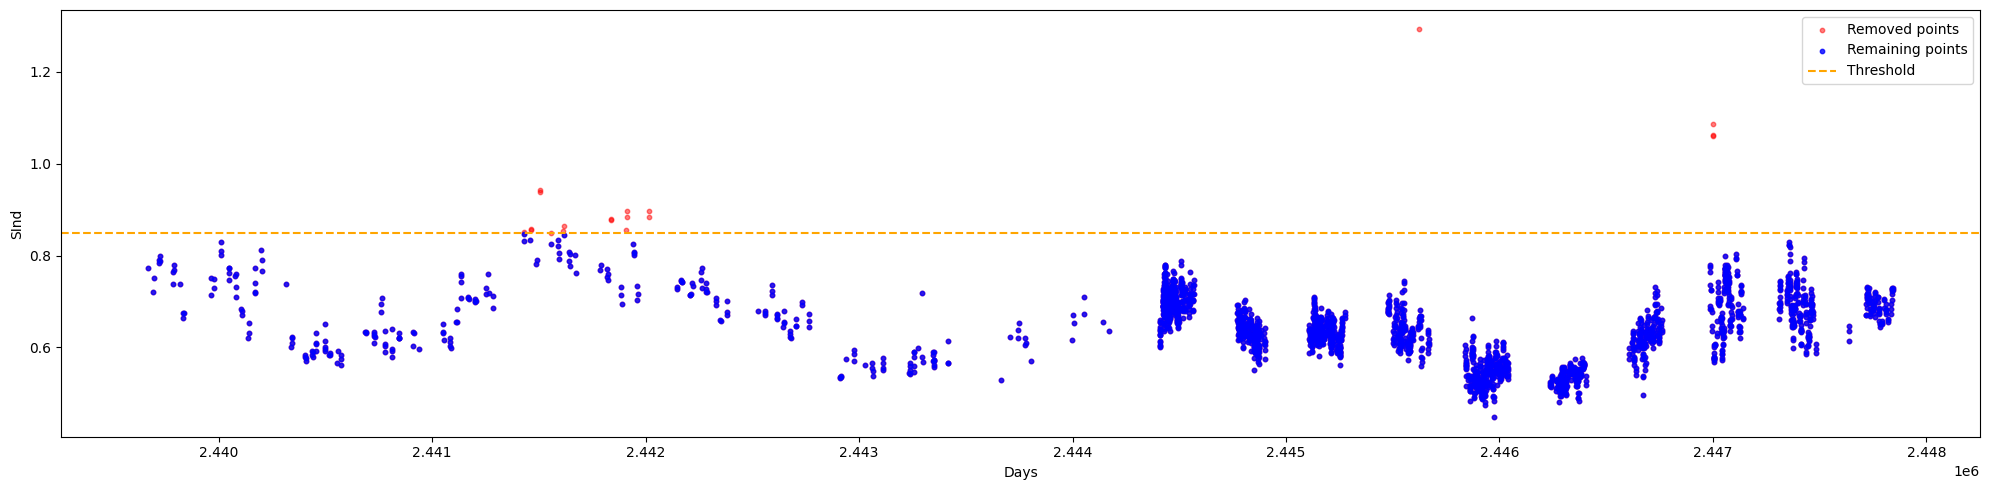

In iteration 0, period at 2730.68 days was accepted.
In iteration 1, period at 12043.36 days was accepted.
Peak at period 1366.67 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.00.
In iteration 2, period at 505.26 days was accepted.
Peak at period 1377.25 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.01.
In iteration 3, period at 290.64 days was accepted.
In iteration 4, period at 36.97 days was accepted.
Peak at period 2070.03 days was identified to be an alias of 505.26 days at mult 4.00 by tolerance 0.02.
In iteration 5, period at 443.94 days was accepted.
Peak at period 36.60 days was identified to be an alias of 36.97 days at mult 1.00 by tolerance 0.01.
In iteration 6, period at 39.89 days was accepted.
In iteration 7, period at 33.32 days was accepted.
Peak at period 156.32 days was identified to be an alias of 39.89 days at mult 4.00 by tolerance 0.02.
Peak at period 252.68 days was identified to be an alias of 50

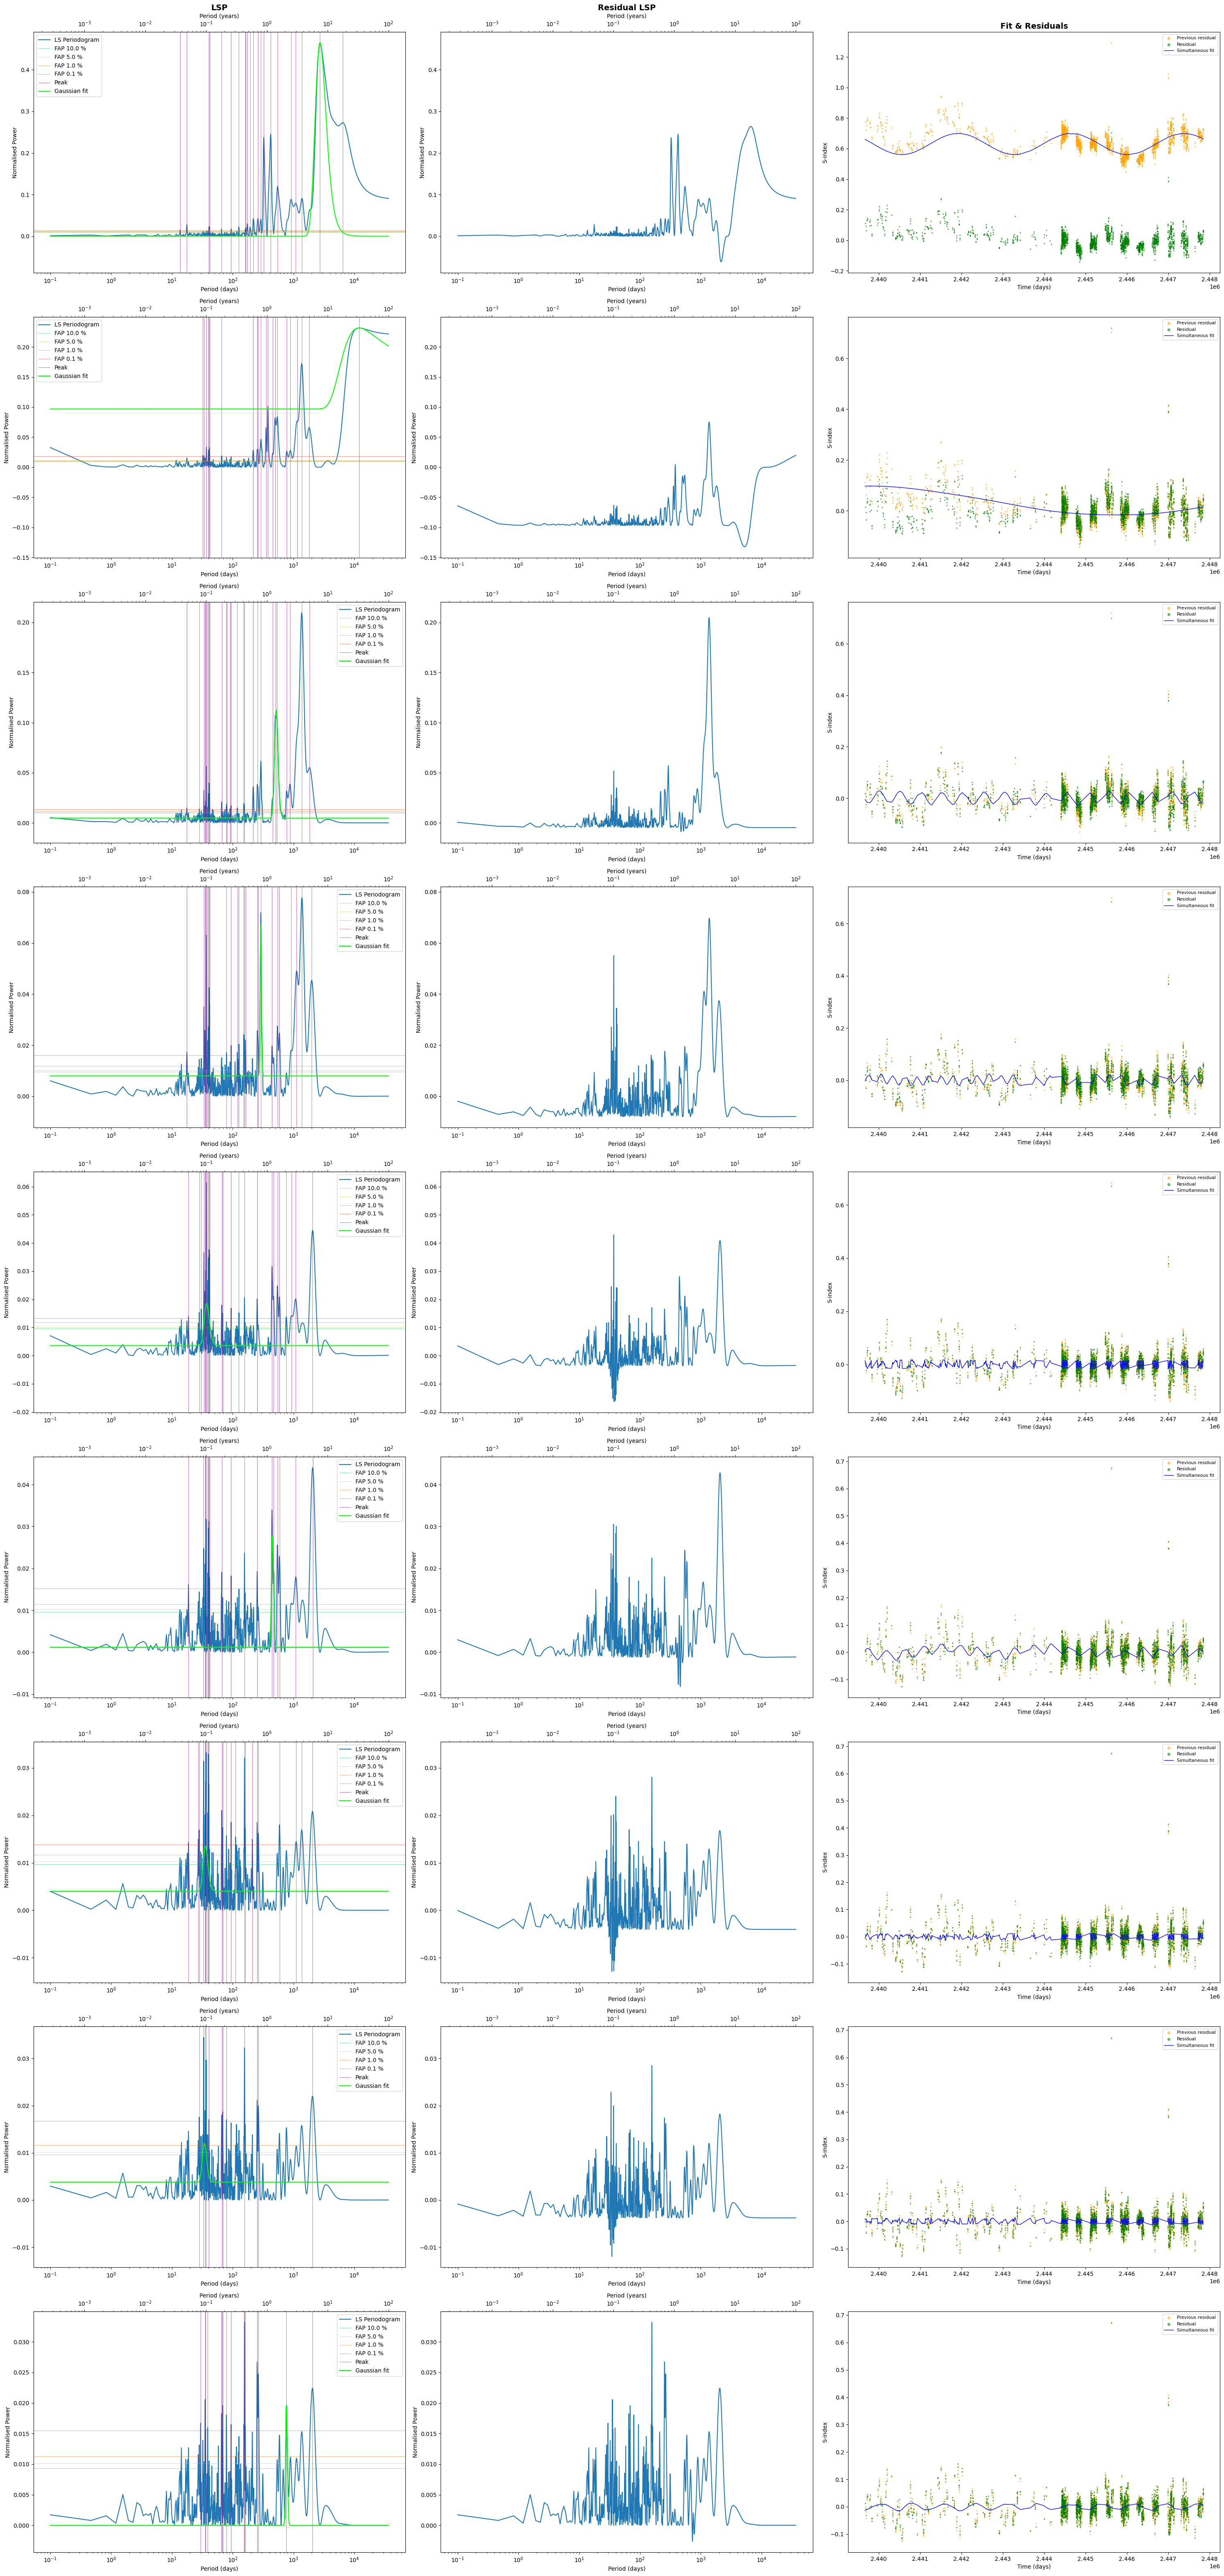

Accepted periods and their heights
+----------+-------+--------+--------------+
|   Days   | Years | Height |     SNR      |
+----------+-------+--------+--------------+
| 2730.68  |  7.48 | 0.4644 |   23570.79   |
| 12043.36 | 33.00 | 0.2316 | 117241745.13 |
|  505.26  |  1.38 | 0.1082 |    18.65     |
|  290.64  |  0.80 | 0.0718 |    10.01     |
|  36.97   |  0.10 | 0.0614 |     9.87     |
|  443.94  |  1.22 | 0.0339 |     7.53     |
|  39.89   |  0.11 | 0.0329 |     6.19     |
|  33.32   |  0.09 | 0.0345 |     7.37     |
|  762.59  |  2.09 | 0.0196 |    13.95     |
+----------+-------+--------+--------------+


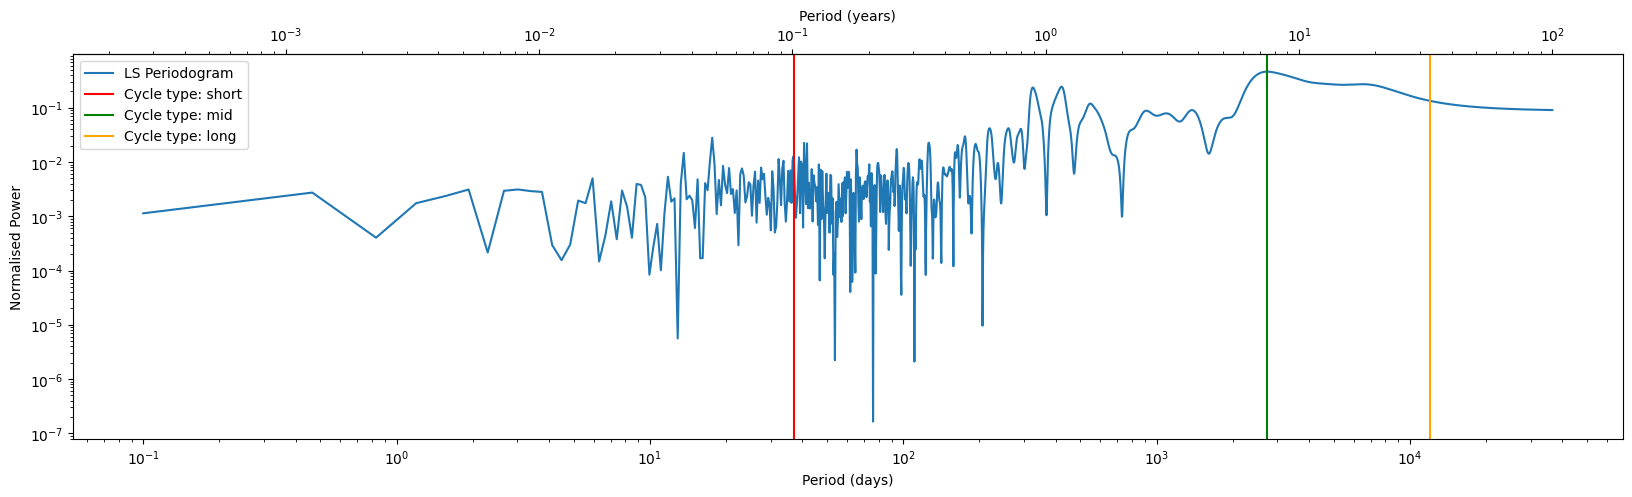

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   36.97    |     0.10    |
|    Mid     |  2730.68   |     7.48    |
|    Long    |  12043.36  |    33.00    |
+------------+------------+-------------+
+------------+------------+-------------+----------------------+----------------+--------+
| Cycle Type | Prior Days | Prior Years |     Bounds Days      |  Bounds Years  | Source |
+------------+------------+-------------+----------------------+----------------+--------+
|   Short    |   36.97    |     0.10    |    (33.27, 40.66)    |  (0.09, 0.11)  | found  |
|    Mid     |  2730.68   |     7.48    |  (2457.62, 3003.75)  |  (6.73, 8.23)  | found  |
|    Long    |  12043.36  |    33.00    | (10839.03, 13247.70) | (29.70, 36.30) | found  |
+------------+------------+-------------+----------------------+----------------+--------+
True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PG

  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [02:00<00:00, 83.19it/s]


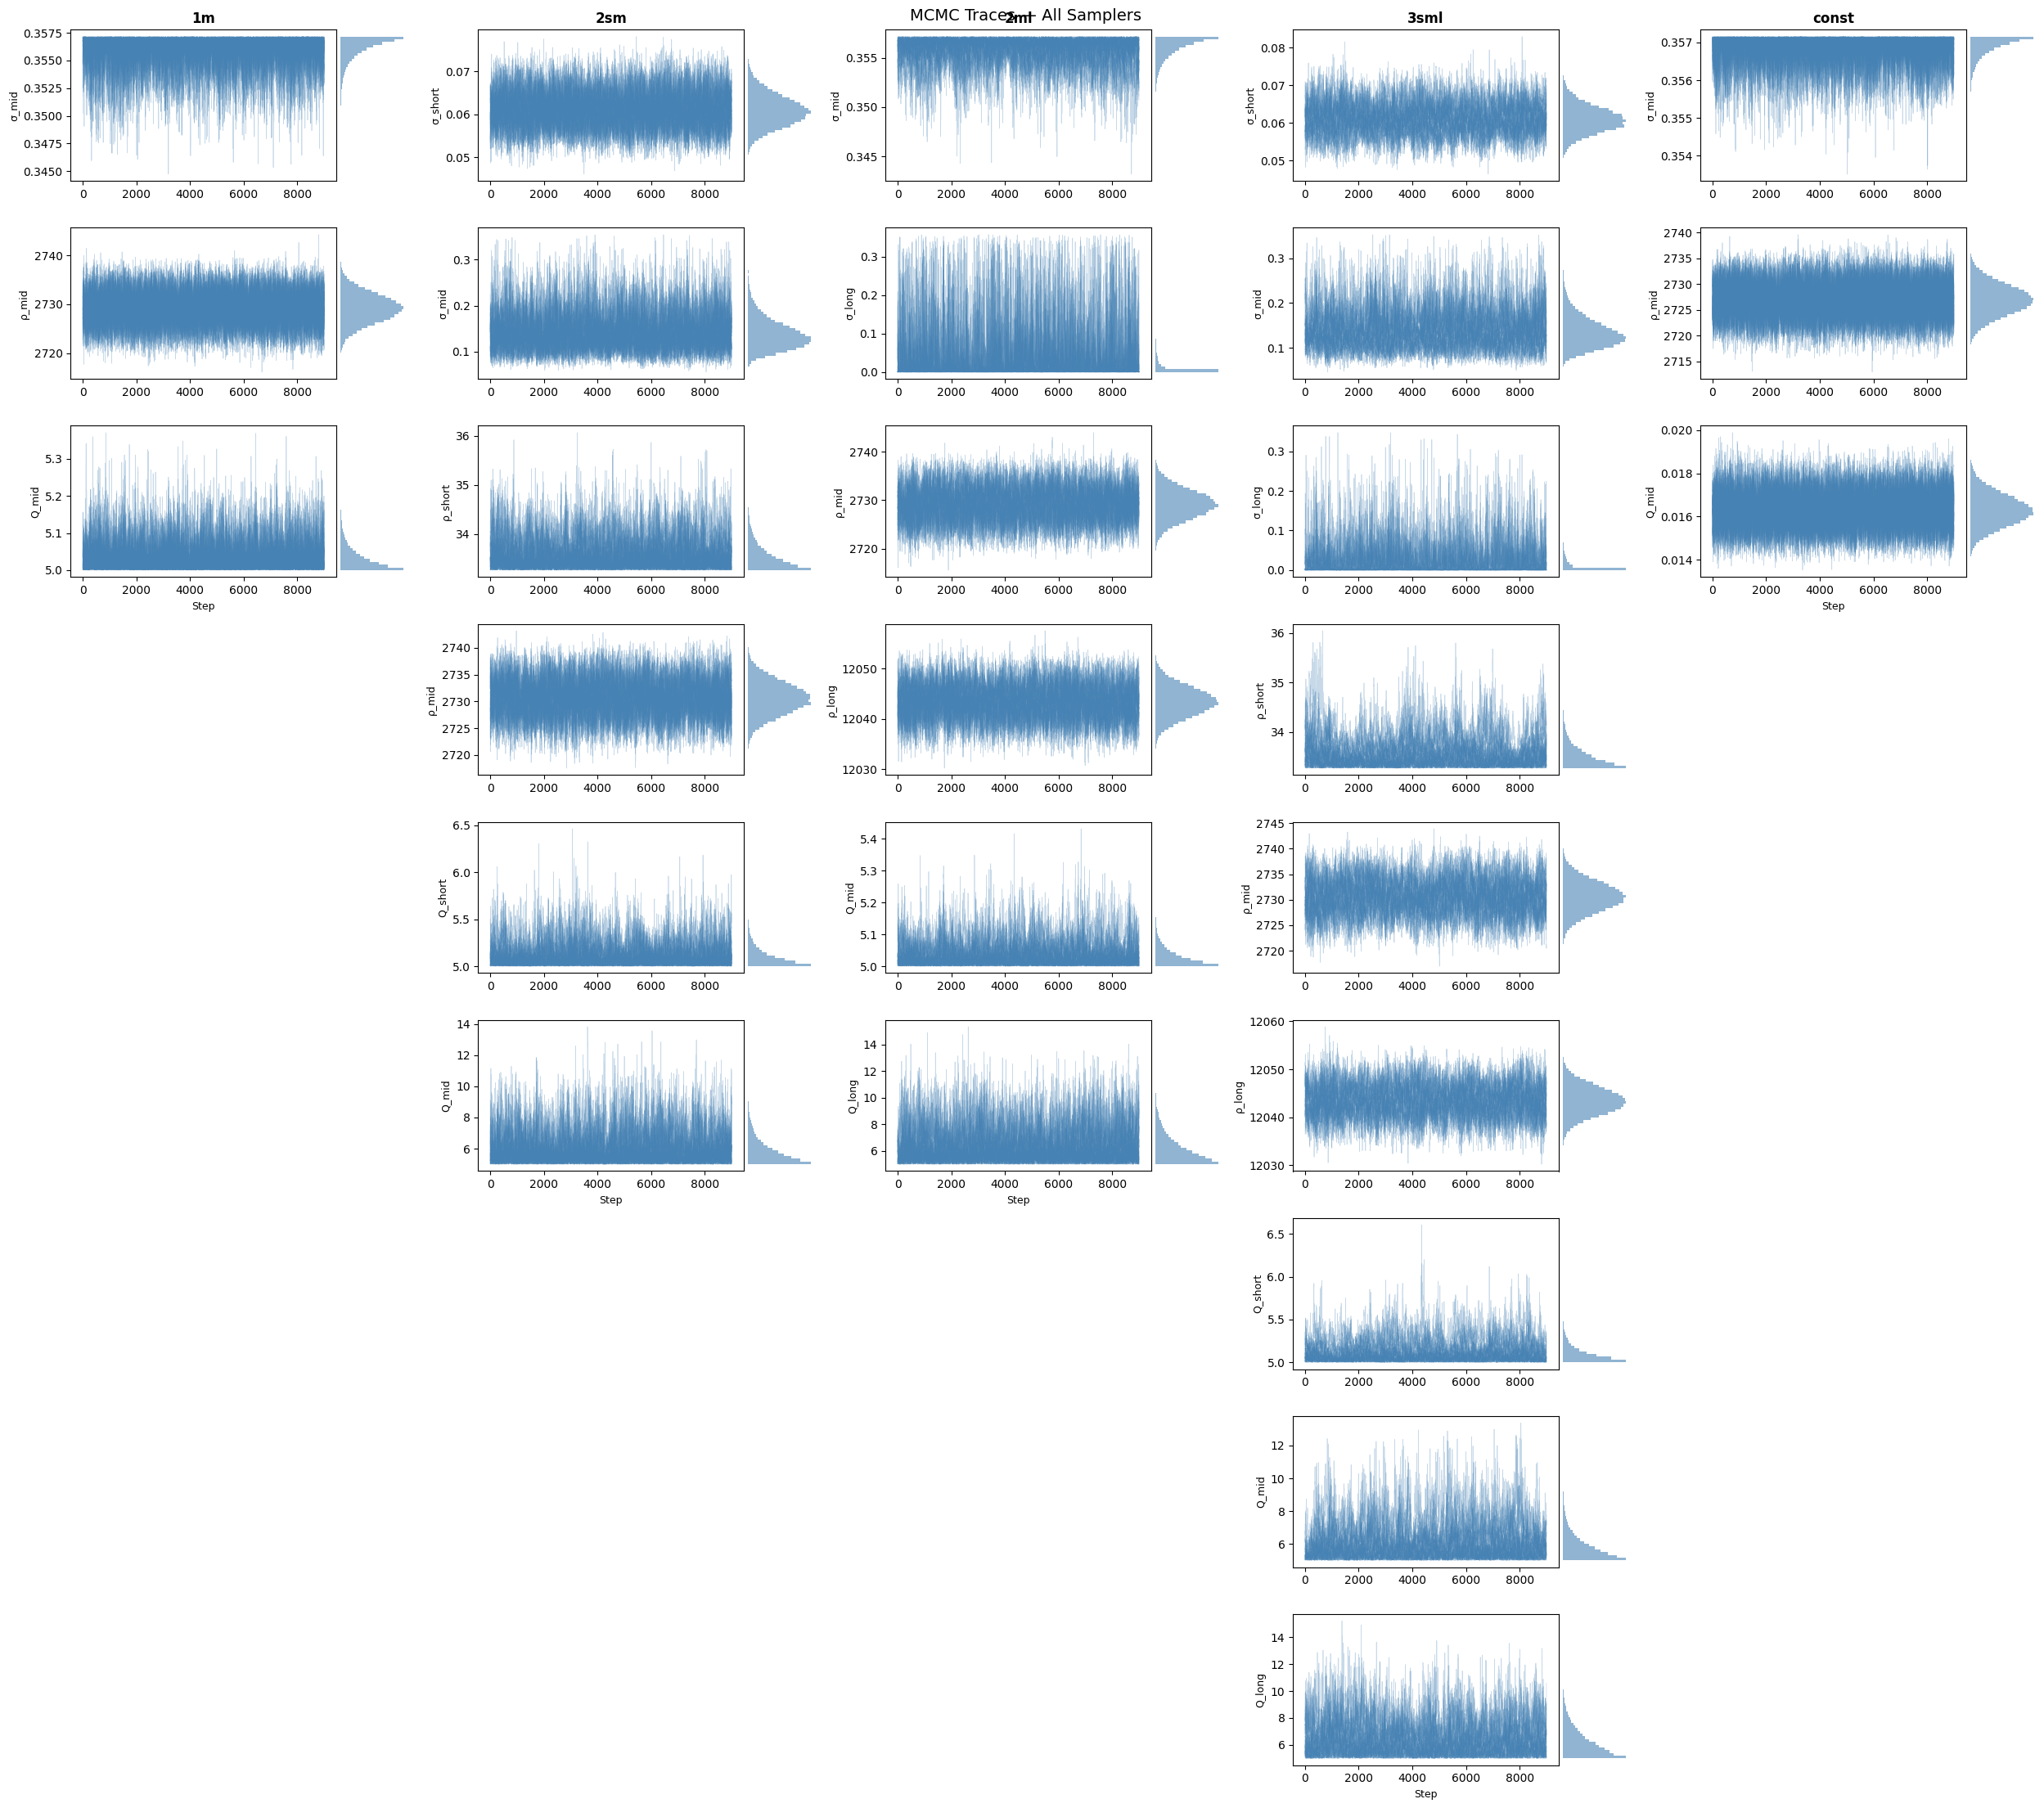

Total BMA samples: 10000


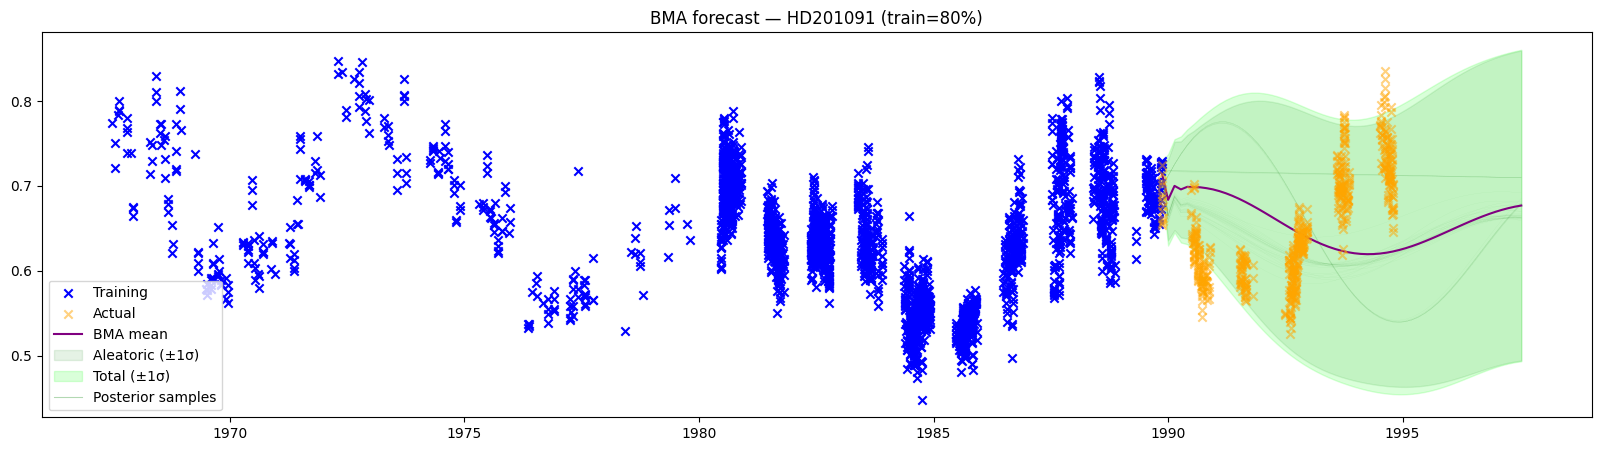

In [5]:
train_gpr(
      datapath          = r"../../Data/benchmark/HD201091_Mt_wilson_data.txt",
      direct_bound_tol  = 0.1,
      sm2016_bound_tol  = 0.2,
      mean_bound_tol    = 1,
      add_prefix        = False,
      relative          = True,
      train_split       = 0.8,
      valid_split       = 0.19,
      star_type         = "G",
      star_name         = "HD201091",
      error_percent     = 2.5,
      sigma_upper_mult  = 5.0,
      q_bounds_in       = [5, 100],
      verbose           = True,
      plot              = True,
      loop_verbose      = True,
      loop_plot         = False,
      loop_savefigs     = False,
      results_verbose   = True,
      results_plot      = True,
      result_plot_cadence = 50,
      result_plot_extra   = 1000,
      require_mid       = True,
      n_walkers         = 32,
      SEED              = 1701,
  )

- The two biggest predictions are out of phase. How can we deal with this?

1/10


  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [00:40<00:00, 244.07it/s]


2/10


  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [00:49<00:00, 203.00it/s]


3/10


...

  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [01:41<00:00, 98.32it/s]


9/10


  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [01:50<00:00, 90.80it/s]


10/10


  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [02:04<00:00, 80.27it/s]


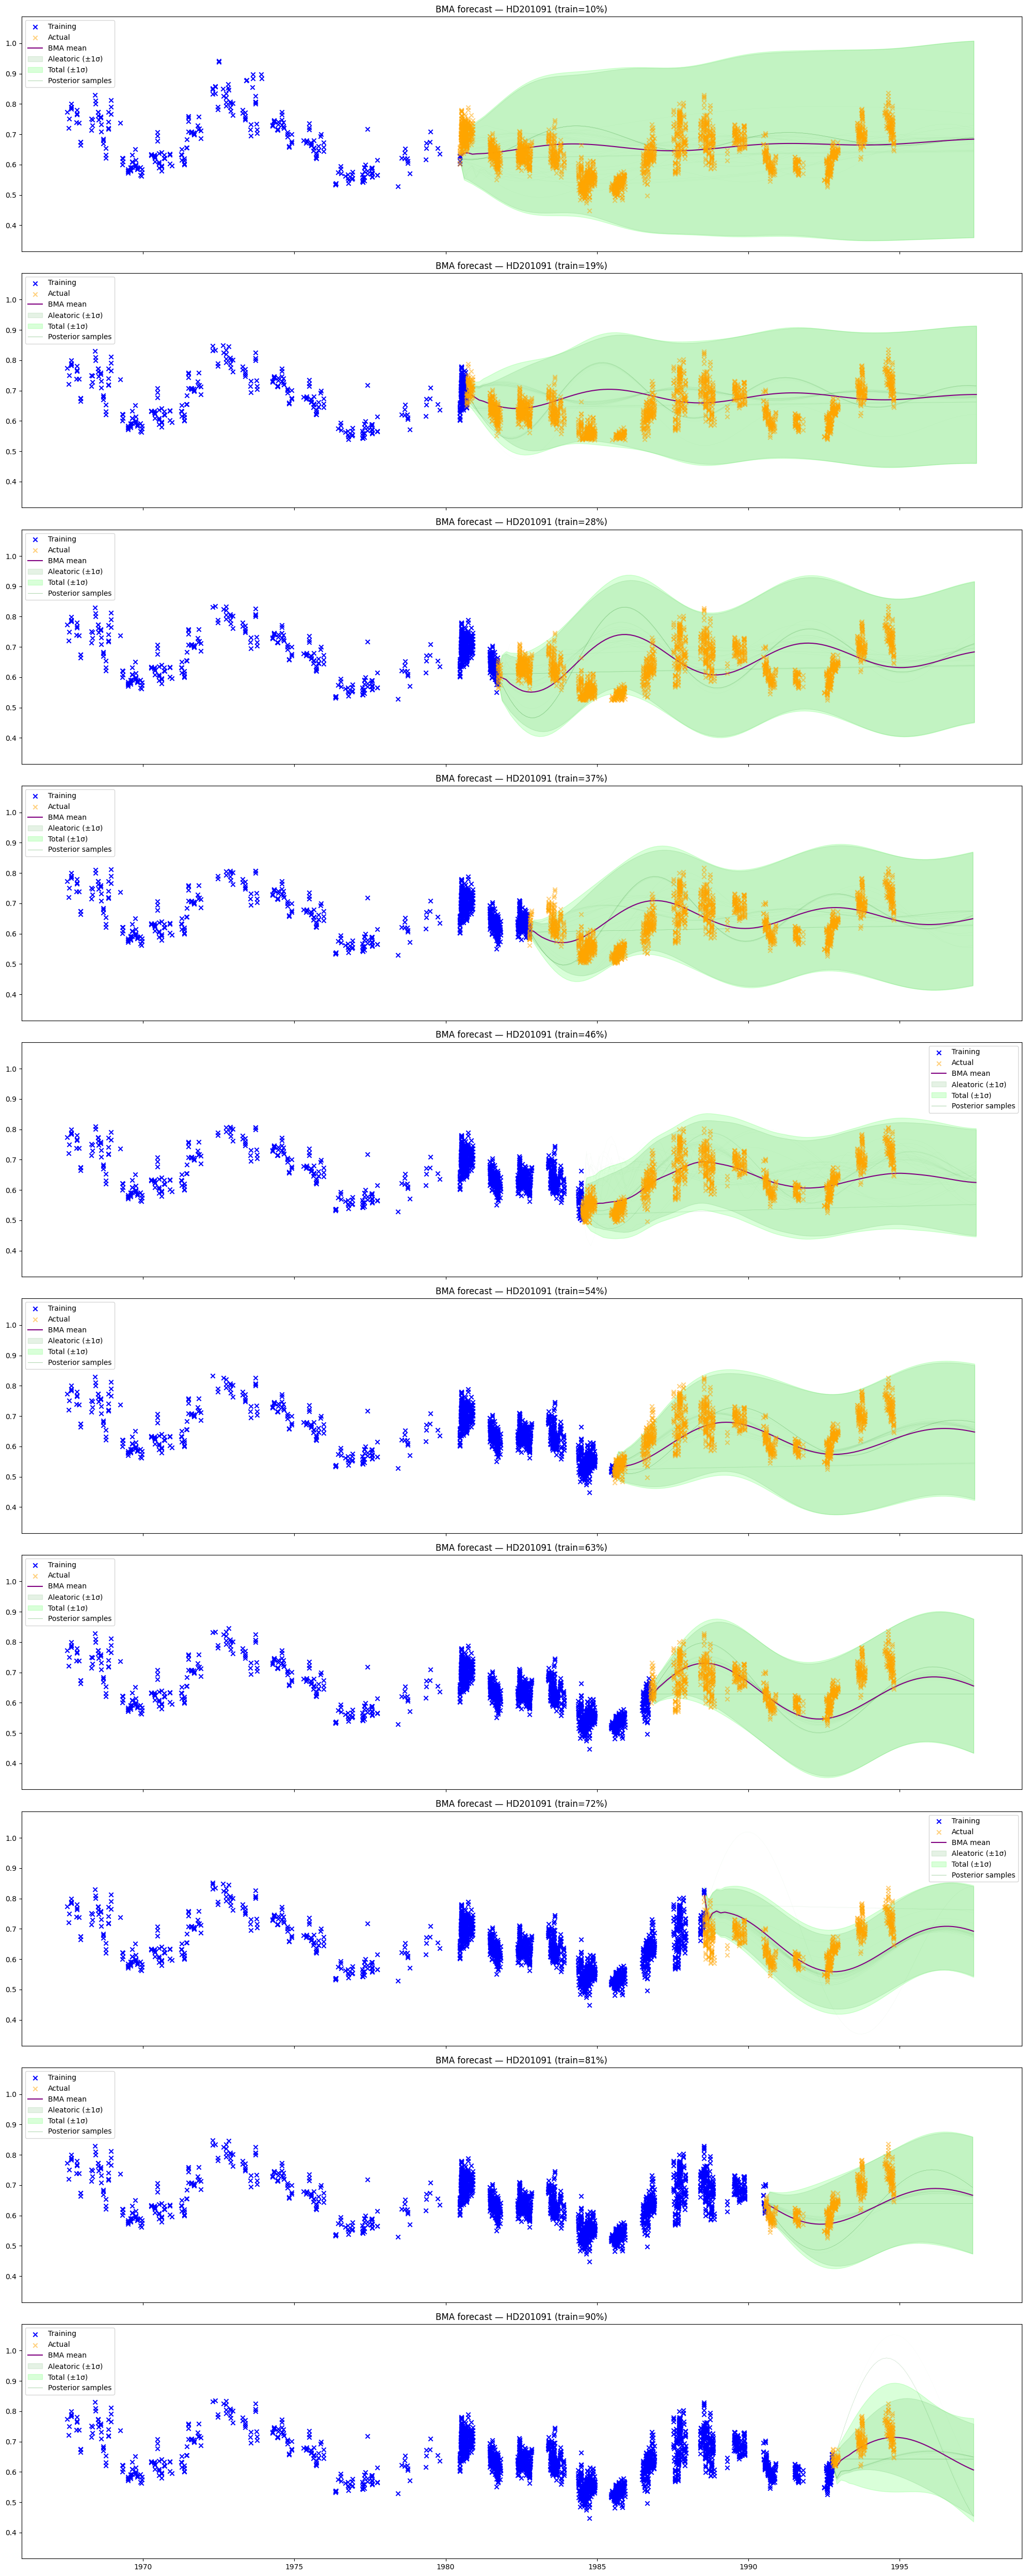

In [6]:
def plot_moving_window(n_windows=10, train_low=0.1, train_high=0.9):
    train_splits = np.linspace(train_low, train_high, n_windows)

    fig, axes = plt.subplots(n_windows, 1, figsize=(20, 5 * n_windows), sharex=True, sharey=True)

    for i, train_split in enumerate(train_splits):
        print(f"{i+1}/{n_windows}")
        valid_split = 0.99 - train_split
        train_gpr(
            datapath        = r"../../Data/benchmark/HD201091_Mt_wilson_data.txt",
            train_split     = train_split,
            valid_split     = valid_split,
            star_name       = 'HD201091',
            star_type       = 'G',
            add_prefix      = False,
            relative        = True,
            verbose         = False,
            plot            = False,
            loop_verbose    = False,
            loop_plot       = False,
            loop_savefigs   = False,
            results_verbose = False,
            results_plot    = False,
            bma_verbose     = False,
            sampler_plot    = False,
            bma_plot        = True,
            require_mid     = True,
            ax              = axes[i],
        )

    fig.tight_layout()
    plt.savefig("moving_window_HD201091.png", dpi=100, bbox_inches='tight')
    plt.show()

plot_moving_window()
